# Anisotropic MeanFlow with α_t Interpolant

**Interpolant formulation:** `z_t = (1 - α_t) ⊙ x + α_t ⊙ ε`

where:
- `α_t = 0` for observed pixels (no noise, stays at data)
- `α_t = t` for masked pixels (interpolates from 0→1 as t goes from 0→1, i.e., from data→noise)
- `⊙` denotes element-wise (Hadamard) product
- At t=0: all pixels are data; At t=1: masked pixels are noise, observed pixels stay as data

**Key features:**
- Spatial conditioning: α_t is interpolated to match each U-Net layer resolution
- Fixed mask structure (box inpainting)
- Modified MeanFlow loss with Jacobian correction terms

In [1]:
# !pip install -q -U einops datasets matplotlib tqdm

%load_ext autoreload
%autoreload 2

import os
import torch
from torch import nn
from torch import einsum
import torch.nn.functional as F
import numpy as np
from torchvision.datasets import MNIST, CIFAR10, CelebA
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
from IPython import display
from tqdm import tqdm

import math
from inspect import isfunction
from functools import partial

from einops import rearrange

from training.networks_amf import SongUNet, AMFPrecond
from torch_utils.resizer import Resizer

import scipy.ndimage
import zipfile

from PIL import Image
import pickle

import lpips
from IPython.display import display, clear_output

from motionblur.motionblur import Kernel

plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['image.cmap'] = 'gray'

os.makedirs('save', exist_ok=True)

seed = 42
from baselines.flow_priors import FLOW_PRIORS
from baselines.d_flow import D_FLOW


## Utility Functions

In [2]:
def grid(array, ncols=8):
    array = np.pad(array, [(0,0),(1,1),(1,1),(0,0)], 'constant')
    nindex, height, width, intensity = array.shape
    ncols = min(nindex, ncols)
    nrows = (nindex+ncols-1)//ncols
    r = nrows*ncols - nindex
    arr = np.concatenate([array]+[np.zeros([1,height,width,intensity])]*r)
    result = (arr.reshape(nrows, ncols, height, width, intensity)
              .swapaxes(1,2)
              .reshape(height*nrows, width*ncols, intensity))
    return np.pad(result, [(1,1),(1,1),(0,0)], 'constant')

class NextDataLoader(torch.utils.data.DataLoader):
    def __next__(self):
        try:
            return next(self.iterator)
        except:
            self.iterator = self.__iter__()
            return next(self.iterator)

def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

class Blurkernel(torch.nn.Module):
    def __init__(self, blur_type='gaussian', kernel_size=5, std=3.0, device=None, channels=3):
        super().__init__()
        self.blur_type = blur_type
        self.kernel_size = kernel_size
        self.std = std
        self.device = device
        self.channels = channels
        self.seq = torch.nn.Sequential(
            torch.nn.ReflectionPad2d(self.kernel_size//2),
            torch.nn.Conv2d(self.channels, self.channels, self.kernel_size, stride=1, padding=0, bias=False, groups=self.channels)
        )

        self.weights_init()

    def forward(self, x):
        return self.seq(x)

    def weights_init(self):
        if self.blur_type == "gaussian":
            n = np.zeros((self.kernel_size, self.kernel_size))
            n[self.kernel_size // 2,self.kernel_size // 2] = 1
            k = scipy.ndimage.gaussian_filter(n, sigma=self.std)
            k = torch.from_numpy(k)
            self.k = k
            for name, f in self.named_parameters():
                f.data.copy_(k)
        elif self.blur_type == "motion":
            k = Kernel(size=(self.kernel_size, self.kernel_size), intensity=self.std).kernelMatrix
            k = torch.from_numpy(k)
            self.k = k
            for name, f in self.named_parameters():
                f.data.copy_(k)

    def update_weights(self, k):
        if not torch.is_tensor(k):
            k = torch.from_numpy(k).to(self.device)
        for name, f in self.named_parameters():
            f.data.copy_(k)

    def get_kernel(self):
        return self.k
    
    def get_fourier(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        half = self.kernel_size // 2
        kernel_padded[:half+1, :half+1] = self.k[half:, half:]
        kernel_padded[-half:, :half+1] = self.k[:half, half:]
        kernel_padded[:half+1, -half:] = self.k[half:, :half]
        kernel_padded[-half:, -half:] = self.k[:half, :half]
        k_fourier = torch.fft.fft2(kernel_padded, dim=[-1, -2])
        return k_fourier
        
    def get_fourier_shift(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        kernel_padded[:self.kernel_size, :self.kernel_size] = self.k
        k_fourier = torch.fft.fftshift(torch.fft.fft2(kernel_padded), dim=[-1, -2])
        return k_fourier

    def get_inverse_fourier(self, img_dim):
        f_kernel = self.get_fourier(img_dim)
        return f_kernel ** -1
    
    def get_inverse_reg_fourier(self, img_dim, epsilon = 1e-8):
        f_kernel = self.get_fourier(img_dim)
        f_kernel_mag_sq = torch.abs(f_kernel)**2
        stabilized_denominator = f_kernel_mag_sq + epsilon
        inverse_filter_fourier = torch.conj(f_kernel) / stabilized_denominator
        return inverse_filter_fourier

class SuperResolutionOperator(nn.Module):
    def __init__(self, in_shape, scale_factor, device):
        super().__init__()
        self.device = device
        self.up_sample = partial(F.interpolate, scale_factor=scale_factor)
        self.down_sample = Resizer(in_shape, 1/scale_factor).to(device)

    def forward(self, data, **kwargs):
        return self.down_sample(data)

    def transpose(self, data, **kwargs):
        return self.up_sample(data)

    def project(self, data, measurement, **kwargs):
        return data - self.transpose(self.forward(data)) + self.transpose(measurement)

class MotionBlurOperator(nn.Module):
    def __init__(self, kernel_size, intensity, device):
        super().__init__()
        self.device = device
        self.kernel_size = kernel_size
        self.conv = Blurkernel(blur_type='motion',
                               kernel_size=kernel_size,
                               std=intensity,
                               device=device).to(device)

        self.kernel_obj = Kernel(size=(kernel_size, kernel_size), intensity=intensity)
        # Convert kernelMatrix to torch tensor immediately for consistency
        self.k = torch.tensor(self.kernel_obj.kernelMatrix, dtype=torch.float32, device=self.device)
        self.conv.update_weights(self.k)
    
    def forward(self, data, **kwargs):
        return self.conv(data)

    def transpose(self, data, **kwargs):
        # Note: For a true transpose (adjoint) in Fourier space, 
        # this would usually involve the complex conjugate of the kernel.
        return data

    def get_kernel(self):
        """Returns the kernel reshaped for convolution layers."""
        return self.k.view(1, 1, self.kernel_size, self.kernel_size)

    def get_fourier(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        half = self.kernel_size // 2
        kernel_padded[:half+1, :half+1] = self.k[half:, half:]
        kernel_padded[-half:, :half+1] = self.k[:half, half:]
        kernel_padded[:half+1, -half:] = self.k[half:, :half]
        kernel_padded[-half:, -half:] = self.k[:half, :half]
        k_fourier = torch.fft.fft2(kernel_padded, dim=[-1, -2])
        return k_fourier
        
    def get_fourier_shift(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        kernel_padded[:self.kernel_size, :self.kernel_size] = self.k
        k_fourier = torch.fft.fftshift(torch.fft.fft2(kernel_padded), dim=[-1, -2])
        return k_fourier

    def get_inverse_fourier(self, img_dim):
        f_kernel = self.get_fourier(img_dim)
        return f_kernel ** -1
    
    def get_inverse_reg_fourier(self, img_dim, epsilon = 1e-8):
        f_kernel = self.get_fourier(img_dim)
        f_kernel_mag_sq = torch.abs(f_kernel)**2
        stabilized_denominator = f_kernel_mag_sq + epsilon
        inverse_filter_fourier = torch.conj(f_kernel) / stabilized_denominator
        return inverse_filter_fourier

from torch.fft  import fftshift, ifftshift

def fft2c_new(data: torch.Tensor, norm: str = "ortho") -> torch.Tensor:
    """
    Apply centered 2 dimensional Fast Fourier Transform.
    Args:
        data: Complex valued input data containing at least 3 dimensions:
            dimensions -3 & -2 are spatial dimensions and dimension -1 has size
            2. All other dimensions are assumed to be batch dimensions.
        norm: Normalization mode. See ``torch.fft.fft``.
    Returns:
        The FFT of the input.
    """
    if not data.shape[-1] == 2:
        raise ValueError("Tensor does not have separate complex dim.")
    
    data = ifftshift(data, dim=[-3, -2])
    data = torch.view_as_real(torch.fft.fftn(torch.view_as_complex(data), dim=(-2, -1), norm=norm))
    data = fftshift(data, dim=[-3, -2])

    return data


def ifft2c_new(data: torch.Tensor, norm: str = "ortho") -> torch.Tensor:
    """
    Apply centered 2-dimensional Inverse Fast Fourier Transform.
    Args:
        data: Complex valued input data containing at least 3 dimensions:
            dimensions -3 & -2 are spatial dimensions and dimension -1 has size
            2. All other dimensions are assumed to be batch dimensions.
        norm: Normalization mode. See ``torch.fft.ifft``.
    Returns:
        The IFFT of the input.
    """
    if not data.shape[-1] == 2:
        raise ValueError("Tensor does not have separate complex dim.")

    data = ifftshift(data, dim=[-3, -2])
    data = torch.view_as_real(
        torch.fft.ifftn(  # type: ignore
            torch.view_as_complex(data), dim=(-2, -1), norm=norm
        )
    )
    data = fftshift(data, dim=[-3, -2])

    return data


def fft2_m(x):
  """ FFT for multi-coil """
  if not torch.is_complex(x):
      x = x.type(torch.complex64)
  return torch.view_as_complex(fft2c_new(torch.view_as_real(x)))


def ifft2_m(x):
  """ IFFT for multi-coil """
  if not torch.is_complex(x):
      x = x.type(torch.complex64)
  return torch.view_as_complex(ifft2c_new(torch.view_as_real(x)))

#@register_operator(name='phase_retrieval')
class PhaseRetrievalOperator(nn.Module):
    # def __init__(self, oversample, device, resolution=128):
    #     super().__init__()
    #     self.pad = int((oversample / 8.0) * resolution)
    #     self.device = device
        
    # def forward(self, data, **kwargs):
    #     data = 0.5 * data + 0.5
    #     padded = F.pad(data, (self.pad, self.pad, self.pad, self.pad))
    #     # print(data)
    #     amplitude = fft2_m(padded).abs()
    #     return amplitude
    def __init__(self, oversample, device, resolution=128):
        super().__init__()
        self.pad = int((oversample / 8.0) * resolution)
        self.device = device
        
    def forward(self, data, **kwargs):
        padded = F.pad(data, (self.pad, self.pad, self.pad, self.pad))
        amplitude = fft2_m(padded).abs()
        return amplitude
    
    def H_pinv(self, x):
        if len(x.shape) == 3:
            x = x.unsqueeze(0)
        x = ifft2_m(x).abs()
        x = self.undo_padding(x, self.pad, self.pad, self.pad, self.pad)
        return x
    
    def undo_padding(self, tensor, pad_left, pad_right, pad_top, pad_bottom):
        # Assuming 'tensor' is the 4D tensor
        # 'pad_left', 'pad_right', 'pad_top', 'pad_bottom' are the padding values
        if tensor.dim() != 4:
            raise ValueError("Input tensor should have 4 dimensions.")
        return tensor[:, :, pad_top : -pad_bottom, pad_left : -pad_right]

class HDR(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, image):
        # Assert that image is in range [-1, 1]
        x = image
        x = torch.clip(x / 0.5, -1, 1)
        return x

    def H_pinv(self, x):
        return x * 0.5    

class Decolorize(nn.Module):
    def __init__(self, channels=3, srf='rec601', device='cpu'):
        super().__init__()
        self.device = device
        if srf is None or srf == 'rec601':
            srf = torch.tensor([0.4472 * 0.66851, 0.8781 * 0.66851, 0.1706 * 0.66851])
        elif srf in ('average', 'flat'):
            srf = torch.tensor([1 / channels] * channels)
        elif srf == 'random':
            srf = torch.rand(channels)
            srf = srf / srf.sum()
        elif isinstance(srf, (tuple, list)):
            srf = torch.tensor(srf)
        else:
            raise ValueError('Invalid srf')

        if srf.size(0) < channels:
            srf = torch.cat([srf, torch.zeros(channels - srf.size(0))])
        elif srf.size(0) > channels:
            raise ValueError('srf should be of length equal to or less than channels.')

        assert torch.allclose(srf.sum(), torch.tensor(1.0), rtol=1e-4)

        self.register_buffer('srf', srf.to(device).view(1, channels, 1, 1))
        self.register_buffer('mask', torch.linalg.vector_norm(self.srf, dim=1, keepdim=True))
        self.to(device)

    def forward(self, data, **kwargs):
        if data.shape[1] != self.srf.shape[1]:
            raise ValueError('data should have same number of channels as SRF.')
        return torch.sum(data * self.srf, dim=1, keepdim=True)

    def transpose(self, data, **kwargs):
        if data.shape[1] != 1:
            raise ValueError('data should be grayscale i.e. have length 1 in the 1st dimension.')
        return data.expand(data.shape[0], self.srf.shape[1], *data.shape[2:]) * self.srf

    def H_pinv(self, x):
        if len(x.shape) == 3:
            x = x.unsqueeze(0)
        if x.shape[1] != 1:
            raise ValueError('x should be grayscale i.e. have length 1 in the 1st dimension.')
        return x.expand(x.shape[0], self.srf.shape[1], *x.shape[2:]) * self.srf / (self.mask ** 2)

class CelebAZip(torch.utils.data.Dataset):
    def __init__(self, zip_path, partition_file, split='test', transform=None):
        self.zip_path = zip_path
        self.transform = transform
        split_map = {'train': 0, 'val': 1, 'test': 2}
        split_id = split_map[split]

        with open(partition_file) as f:
            entries = [line.strip().split() for line in f]

        valid = {e[0].replace('.jpg', '.png') for e in entries if int(e[1]) == split_id}

        with zipfile.ZipFile(zip_path) as z:
            self.names = sorted(n for n in z.namelist() if n in valid)

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        with zipfile.ZipFile(self.zip_path) as z:
            with z.open(self.names[idx]) as f:
                img = Image.open(f).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0


## Mask Generation

Generate binary masks where:
- `mask = 1`: observed pixels
- `mask = 0`: pixels to inpaint

**Random box sizes:** During training, box sizes are randomized from 1 pixel to the full image size for better generalization!

In [3]:
def generate_box_mask(batch_size, channels, height, width, box_size=16, device='cuda'):
    """
    Generate center box masks for inpainting.
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box)
    """
    mask = torch.ones(batch_size, channels, height, width, device=device)
    start = (height - box_size) // 2
    end = start + box_size
    mask[:, :, start:end, start:end] = 0
    return mask

def generate_random_box_mask(batch_size, channels, height, width, min_box_size=1, max_box_size=None, device='cuda'):
    """
    Generate center box masks with RANDOM box sizes for each sample in the batch.
    
    Args:
        batch_size: number of samples
        channels: number of channels
        height, width: image dimensions
        min_box_size: minimum box size (default: 1 pixel)
        max_box_size: maximum box size (default: full image size)
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box with random size per sample)
    """
    if max_box_size is None:
        max_box_size = min(height, width)
    
    masks = []
    for _ in range(batch_size):
        # Randomly sample box size for this sample
        box_size = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
        
        # Create mask for this sample
        mask = torch.ones(channels, height, width, device=device)
        start = (height - box_size) // 2
        end = start + box_size
        mask[:, start:end, start:end] = 0
        masks.append(mask)
    
    return torch.stack(masks, dim=0)

def generate_random_mask(batch_size, channels, height, width, mask_ratio=0.5, device='cuda'):
    """
    Generate random pixel masks for inpainting.
    
    Args:
        mask_ratio: proportion of pixels to mask
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked
    """
    mask = torch.rand(batch_size, channels, height, width, device=device)
    mask = (mask > mask_ratio).float()
    return mask

def generate_box_alpha(alpha, img_size):
    size_box = int(img_size / alpha.shape[-1])
    noise_mask = alpha.repeat_interleave(size_box, dim=2).repeat_interleave(size_box, dim=3)  # Upsample to (5, 1, 4, 4) for 4 boxespr
    return noise_mask

## Alpha Schedule and Interpolant

**Alpha schedule (Standard Diffusion Convention):**
- `α_t = (1 - mask) * t`
- Observed pixels (mask=1): `α_t = 0` (always at data)
- Masked pixels (mask=0): `α_t = t` (goes from 0→1, i.e., data→noise)

**Interpolant:**
- `z_t = (α_t) ⊙ x + (1 - α_t) ⊙ ε`
- At t=1: `z_1 = x` (all data)
- At t=0: `z_0 = mask ⊙ x + (1-mask) ⊙ ε` (observed=data, masked=noise)

**Velocity:**
- `dz_t/dt = -x·dα_t/dt + ε·dα_t/dt = (ε - x)·dα_t/dt`
- `dα_t/dt = (1 - mask)` (only masked pixels change)
- `v = (1 - mask) ⊙ (ε - x)`

In [4]:
# def compute_alpha_t(t, mask):
#     """
#     Compute α_t from time and mask.

#     Args:
#         t: time parameter [B, 1, 1, 1], ranges from 0 (data) to 1 (noise)
#         mask: binary mask [B, C, H, W], 1 = observed, 0 = masked

#     Returns:
#         α_t: [B, C, H, W]
#     """
#     # α_t = (1 - mask) * (1 -t
#     # Observed (mask=1): α_t = 1 (always at data)
#     # Masked (mask=0): α_t = t (goes from data to noise)
#     # alpha_t = mask + (1 - mask) * t
#     alpha_t = (1 - mask) * (1 - t)
#     return alpha_t

def compute_alpha_t(t, mask):
    """
    Compute α_t from time and mask.
    Convention: higher alpha = cleaner (alpha=1 is data, alpha=0 is noise)
    Args:
        t: time parameter [B, 1, 1, 1], ranges from 0 (noise) to 1 (data)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
    Returns:
        α_t: [B, C, H, W]
        - Observed (mask=1): α_t = 1 (always clean)
        - Masked  (mask=0): α_t = t (interpolates noise→data as t: 0→1)
    """
    alpha_t = mask + (1 - mask) * t
    return alpha_t


def sample_interpolant(x, t, mask, eps=None):
    """
    Sample from the interpolant: z_t = α_t ⊙ x + (1 - α_t) ⊙ ε
    Convention: higher alpha = cleaner (alpha=1 is data, alpha=0 is noise)
    Args:
        x: clean data [B, C, H, W]
        t: time [B, 1, 1, 1], ranges from 0 (noise) to 1 (data)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
        eps: noise (optional, will sample if not provided)
    Returns:
        z_t: interpolated sample [B, C, H, W]
        alpha_t: interpolation coefficients [B, C, H, W]
        eps: noise used [B, C, H, W]
        v_true: true velocity field [B, C, H, W]
        drift: (x - eps) [B, C, H, W]
    """
    if eps is None:
        eps = torch.randn_like(x)

    # alpha=1 clean, alpha=0 noise
    # Observed (mask=1): alpha=1 always → z = x
    # Masked  (mask=0): alpha=t → t=1: z=x, t=0: z=eps
    alpha_t = compute_alpha_t(t, mask)

    # Interpolant: z_t = alpha_t * x + (1 - alpha_t) * eps
    z_t = alpha_t * x + (1 - alpha_t) * eps

    # Velocity: dz/dt = d(alpha_t)/dt * (x - eps)
    # d(alpha_t)/dt = (1 - mask)
    drift = x - eps
    v_true = (1 - mask) * drift

    return z_t, alpha_t, eps, v_true, drift

In [5]:
@torch.inference_mode()
def sample(net, alpha_start, x_observed=None, num_steps=1, device='cuda'):
    """
    alpha_start: [B, C, H, W]  initial per-pixel alpha
                  (0 for masked pixels, 1 for observed pixels)
    x_observed:  [B, C, H, W]  known pixel values

    Integrates from alpha_start → 1 per pixel.
    """
    B, C, H, W = alpha_start.shape

    if x_observed is None:
        x_observed = torch.zeros(B, C, H, W, device=device)

    eps   = torch.randn(B, C, H, W, device=device)
    z   = alpha_start * x_observed + (1 - alpha_start) * eps
    x_init = z.clone()

    t_values = torch.linspace(0.0, 1.0, num_steps + 1, device=device)

    for i in range(num_steps):
        t_cur  = t_values[i]
        t_next = t_values[i + 1]
        # per-pixel alpha: interpolate from alpha_start to 1
        alpha_r = alpha_start + t_cur  * (1 - alpha_start)  # (B, C, H, W)
        alpha_t = alpha_start + t_next * (1 - alpha_start)

        v_pred = net(z, alpha_r[:, :1], alpha_t[:, :1])
        z = z + (alpha_t - alpha_r) * v_pred

    return z, x_init

## Run Training

In [6]:
device = 'cuda:7' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

data = 'afhq'  # 'mnist' or 'cifar10' or 'celeba'

# Create model
if data == 'afhq':
    img_size = 256 #192
    net = AMFPrecond(
        img_resolution=img_size,
        img_channels=3,
        model_channels=128,  # 64 or 128,  # Base multiplier for the number of channels.
        channel_mult=[1, 2, 3, 4],    # Per-resolution multipliers for the number of channels.
        num_blocks=3,
        attn_resolutions=[16,8],
        use_weight=True,
        anisotropic_noise=False,
    ).to(device)
elif data == 'celeba':
    # img_size = 64
    # net = AMFPrecond(
    #     img_resolution=img_size,
    #     img_channels=3,
    #     model_channels=128,  # 64 or 128,  # Base multiplier for the number of channels.
    #     channel_mult=[1, 2, 2, 2],    # Per-resolution multipliers for the number of channels.
    #     num_blocks=4,
    #     use_weight=True,
    #     anisotropic_noise=False,
    # ).to(device)
    img_size = 128
    net = AMFPrecond(
        img_resolution=img_size,
        img_channels=3,
        model_channels=128,  # 64 or 128,  # Base multiplier for the number of channels.
        channel_mult=[1, 2, 3, 4],    # Per-resolution multipliers for the number of channels.
        num_blocks=3,
        attn_resolutions=[16,8],
        use_weight=True,
        anisotropic_noise=False,
    ).to(device)

print(f"Model parameters: {sum(p.numel() for p in net.parameters()):,}")
loss_fn_alex = lpips.LPIPS(net='alex').to(device) # best forward scores.to(device)

Using device: cuda:7
Model parameters: 112,836,739
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/nvidia/diffusion/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nvidia/diffusion/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/nvidia/diffusion/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


In [ ]:
# min_box_size = 5  # Minimum box size (from 1 pixel...)
# max_box_size = 20  # Maximum box size (up to full image size, which

# checkpoint = torch.load('/home/nvidia/easy_meanflow/logs/aniso_flow_map/lsd_correct_partition/00023-mnist-32x32-uncond-ddpmpp-mf-gpus3-batch510-fp32/network-snapshot-060588.pkl', weights_only=False)
# net.load_state_dict(checkpoint['model'])
# net.eval()

# # Test
# batch_size = 16

# test_dataset = MNIST(
#     'data',
#     train=False,
#     transform=transforms.Compose(list(filter(None, [
#         transforms.Resize((img_size, img_size)) if img_size is not None else None,
#         transforms.Grayscale(),
#         transforms.ToImage(),
#         transforms.ToDtype(torch.float32, scale=True),
#     ]))),
#     download=True
# )
# dataloader = NextDataLoader(
#     test_dataset, batch_size, num_workers=4, prefetch_factor=2, pin_memory=True
# )
# img = next(dataloader)[0]  # [1, 1, 32, 32]

# num_steps = 1
# alpha_start = torch.zeros_like(img).to(device)  # Start with all noise (alpha=0)
# with torch.no_grad():
#     z, x_init = sample(net, alpha_start, device=device, num_steps=num_steps)

# # Visualize
# x_reconstr = z.detach().permute(0,2,3,1).clamp(0,1)
# x_obs = torch.clamp(x_init.permute(0,2,3,1).cpu(), 0, 1)
# x_original = img.detach().permute(0,2,3,1).cpu()

# plt.figure(figsize=(12, 5))

# plt.subplot(1, 3, 1)
# plt.title('Inpainted Images')
# plt.imshow(grid(x_reconstr.cpu()).squeeze())
# plt.axis('off')

# plt.subplot(1, 3, 2)
# plt.title('Observed Images')
# plt.imshow(grid(x_obs).squeeze())
# plt.axis('off')

# plt.subplot(1, 3, 3)
# plt.title('Original Images')
# plt.imshow(grid(x_original.cpu()).squeeze())
# plt.axis('off')

# plt.tight_layout()
# plt.show()

## Test and Visualize

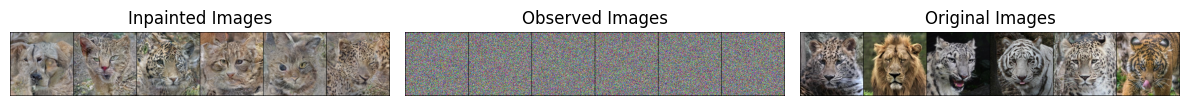

In [8]:
if data == 'cifar10':
    with open('/home/nvidia/easy_meanflow/logs/aniso_flow_map/lsd_correct_partition/00024-cifar10-32x32-uncond-ddpmpp-mf-gpus4-batch512-fp32/network-snapshot-100000.pkl', 'rb') as f:
        checkpoint = pickle.load(f)
elif data == 'celeba':
    with open('/home/nvidia/easy_meanflow/logs/aniso_flow_map/lsd/00054-celeba-128x128-uncond-ddpmpp-mf-gpus8-batch128-fp32/network-snapshot-087584.pkl', 'rb') as f:
        checkpoint = pickle.load(f)
elif data == 'afhq':
    # with open('/home/nvidia/easy_meanflow/logs/aniso_flow_map/lsd/00058-afhq-256x256-uncond-ddpmpp-mf-gpus8-batch32-fp32/network-snapshot-017505.pkl', 'rb') as f:
    with open('/home/nvidia/flow_maps/logs/aniso_flow_map/flow_matching_model/00001-afhq-256x256-uncond-ddpmpp-mf-gpus4-batch32-fp32/network-snapshot-002500.pkl', 'rb') as f:
        checkpoint = pickle.load(f)

net = checkpoint['ema']  # or 'net' — check keys below
net.eval().to(device)


# Test
batch_size = 6

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    # box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    box_size_i = 15
    # test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.7, device=device))
    test_mask.append(generate_random_box_mask(1, 1, img_size, img_size, min_box_size=box_size_i, max_box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]

if data == 'mnist':
    test_dataset = MNIST(
        'data',
        train=False,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.Grayscale(),
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize([0.5], [0.5]),
        ]))),
        download=True
    )
elif data == 'cifar10':
    test_dataset = CIFAR10(
        'data',
        train=False,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ]))),
        download=True
    )
elif data == 'celeba':
    test_dataset = CelebAZip(
        zip_path='/home/nvidia/flow_maps/data/celeba/celeba-128x128.zip',
        partition_file='/home/nvidia/flow_maps/data/celeba/list_eval_partition.txt',
        split='test',
        transform=transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
    )
elif data == 'afhq':
    from training.dataset import ImageFolderDataset
    _base = ImageFolderDataset(
        path='/home/nvidia/flow_maps/data/afhq-256x256.zip',
        split='test',
        train_ratio=0.9,
    )
    class _AFHQWrapper(torch.utils.data.Dataset):
        def __len__(self): return len(_base)
        def __getitem__(self, idx):
            img_np, label = _base[idx]  # CHW uint8
            return torch.from_numpy(img_np).float() / 127.5 - 1, label
    test_dataset = _AFHQWrapper()

dataloader = NextDataLoader(
    test_dataset, batch_size, num_workers=1, prefetch_factor=2, pin_memory=True
)
img = next(dataloader)[0]  # [1, 1, 32, 32]

num_steps = 15
alpha_start = torch.zeros_like(img).to(device)  # Start with all noise (alpha=0)
with torch.no_grad():
    z, x_init = sample(net, alpha_start, device=device, num_steps=num_steps)

# Visualize
x_reconstr = ((z+1)/2).detach().permute(0,2,3,1).clamp(0,1)
x_obs = ((x_init + 1) / 2).permute(0,2,3,1).clamp(0, 1).cpu()
x_original = ((img.detach() + 1) / 2).permute(0,2,3,1).cpu()

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title('Inpainted Images')
plt.imshow(grid(x_reconstr.cpu()).squeeze())
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Observed Images')
plt.imshow(grid(x_obs).squeeze())
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Original Images')
plt.imshow(grid(x_original.cpu()).squeeze())
plt.axis('off')

plt.tight_layout()
plt.show()

## Inpainting

In [ ]:
# seed = 10

# torch.manual_seed(seed)
# np.random.seed(seed)
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)


# N = 10 # Number of time steps
# alpha = 0.01  # Exponent in the learning rate
# delta = 1 / N  # Time step size
# x = torch.zeros((batch_size, 1, 32, 32)).to(device)
# # fig, ax = plt.subplots()

# noise_std = 5e-4
# noisy_img = test_mask * img.to(device) + noise_std * torch.randn_like(img.to(device))

# for i in range(N):
#     print(f"Time step {i+1}/{N}")
#     with torch.no_grad():

#         t = torch.ones(len(x), device=device) * delta * i

#         # Gradient step on the data-fidelity term
#         lr_t = (1 - t).view(-1, 1, 1, 1)**alpha
#         z = x - lr_t * test_mask * (test_mask * x - noisy_img)  # H is symmetric

#         # Interpolation step
#         z_tilde = t.view(-1, 1, 1, 1) * z + \
#             torch.randn_like(x) * (1 - t.view(-1, 1, 1, 1))

#         # Denoising step. Denoiser = z + (1 - t) * net(z, t, t)
#         x_new = z_tilde + (1 - t.view(-1, 1, 1, 1)) * net(z_tilde, t.view(-1, 1, 1, 1), t.view(-1, 1, 1, 1))
        
#         # Update the solution
#         x = x_new.clone()

#         # Plot the current image
# #         if i % 5 == 0 or i == N - 1:
# #             clear_output(wait=True)
# #             ax.imshow(torch.clip((x[0].cpu()),
# #                       0, 1).permute(1, 2, 0), vmin=0, vmax=1)
# #             ax.axis('off')
# #             ax.set_title(
# #                 'Reconstructed image at time t={:4.2f}'.format(delta * i))
# #             display(fig)

# # clear_output(wait=False)

# x_reconstr_pnp = x.detach().permute(0,2,3,1).clamp(0,1)

In [ ]:
# noise_std = 1e-3
# noisy_img = test_mask * img.to(device) + noise_std * torch.randn_like(img.to(device))

# for lookahead_window in [0.0, 0.1, 0.2, 0.5, 1.0]:
#     torch.manual_seed(seed)
#     np.random.seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)


#     N = 10 #N 
#     alpha = 0.01  # Exponent in the learning rate
#     delta = 1 / N  # Time step size
#     x = torch.zeros((batch_size, 1, 32, 32)).to(device)
#     # fig, ax = plt.subplots()  

#     for i in range(0, N):
#         print(f"Time step {i+1}/{N}")
#         with torch.no_grad():

#             t = torch.ones(len(x), device=device) * delta * i
            
#             # NEW: Calculate the target time for the secant line.
#             # We clamp it at 1.0 because 1.0 is the end of the flow (clean image).
#             t_target = torch.clamp(t + lookahead_window, max=1.0)

#             # Gradient step on the data-fidelity term
#             lr_t = (1 - t).view(-1, 1, 1, 1)**alpha
#             z = x - lr_t * test_mask * (test_mask * x - noisy_img)  # H is symmetric

#             # Interpolation step
#             z_tilde = t.view(-1, 1, 1, 1) * z + \
#                 torch.randn_like(x) * (1 - t.view(-1, 1, 1, 1))


#             x_new = z_tilde + (1 - t.view(-1, 1, 1, 1)) * net(z_tilde, t.view(-1, 1, 1, 1), t_target.view(-1, 1, 1, 1))
            
#             # Update the solution
#             x = x_new.clone()

#     x_reconstr_fm_pnp = x.detach().permute(0,2,3,1).clamp(0,1)
#     x_obs = torch.clamp(noisy_img.permute(0,2,3,1).cpu(), 0, 1)
#     x_original = img.detach().permute(0,2,3,1).cpu()

#     plt.figure(figsize=(12, 5))

#     plt.subplot(1, 3, 1)
#     plt.title(f'Rec. - Global flow map w/lookahead {lookahead_window}')
#     plt.imshow(grid(x_reconstr_fm_pnp.cpu()).squeeze())
#     plt.axis('off')

#     plt.subplot(1, 3, 2)
#     plt.title('Observed Images')
#     plt.imshow(grid(x_obs).squeeze())
#     plt.axis('off')

#     plt.subplot(1, 3, 3)
#     plt.title('Original Images')
#     plt.imshow(grid(x_original.cpu()).squeeze())
#     plt.axis('off')

#     # plt.subplot(1, 4, 4)
#     # plt.title('Reconstruction original PnP')
#     # plt.imshow(grid(x_reconstr_pnp.cpu()).squeeze())
#     # plt.axis('off')

#     plt.tight_layout()
#     plt.show()

#     # Compute PSNR
#     def compute_psnr(img1, img2):
#         mse = F.mse_loss(img1, img2)
#         if mse == 0:
#             return float('inf')
#         max_pixel = 1.0  # Assuming images are in [0, 1]
#         psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
#         return psnr.item()

#     # psnr_pnp = compute_psnr(x_reconstr_pnp.cpu(), x_original)
#     psnr_fm_pnp = compute_psnr(x_reconstr_fm_pnp.cpu(), x_original)

#     # print(f"PSNR of original PnP: {psnr_pnp:.2f} dB")
#     print(f"PSNR of flow map PnP with lookahead {lookahead_window}: {psnr_fm_pnp:.2f} dB")
#     with torch.no_grad():
#         # lpips_pnp = 0.0
#         lpips_fm_pnp = 0.0
#         for idx in range(x_reconstr_fm_pnp.shape[0]):
#             # lpips_pnp = loss_fn_alex(x_reconstr_pnp[idx:idx+1].to(device).permute(0,3,1,2), x_original[idx:idx+1].to(device).permute(0,3,1,2)).item() + lpips_pnp
#             lpips_fm_pnp = loss_fn_alex(x_reconstr_fm_pnp[idx:idx+1].to(device).permute(0,3,1,2), x_original[idx:idx+1].to(device).permute(0,3,1,2)).item() + lpips_fm_pnp

#     # print(f"LPIPS of original PnP: {lpips_pnp/x_reconstr_fm_pnp.shape[0]:.4f}")
#     print(f"LPIPS of flow map PnP with lookahead {lookahead_window}: {lpips_fm_pnp/x_reconstr_fm_pnp.shape[0]:.4f}")

N=200, lookahead=0.0 | PSNR=24.35dB
N=200, lookahead=0.0 | MSE=0.00367
N=200, lookahead=0.0 | LPIPS=0.1531


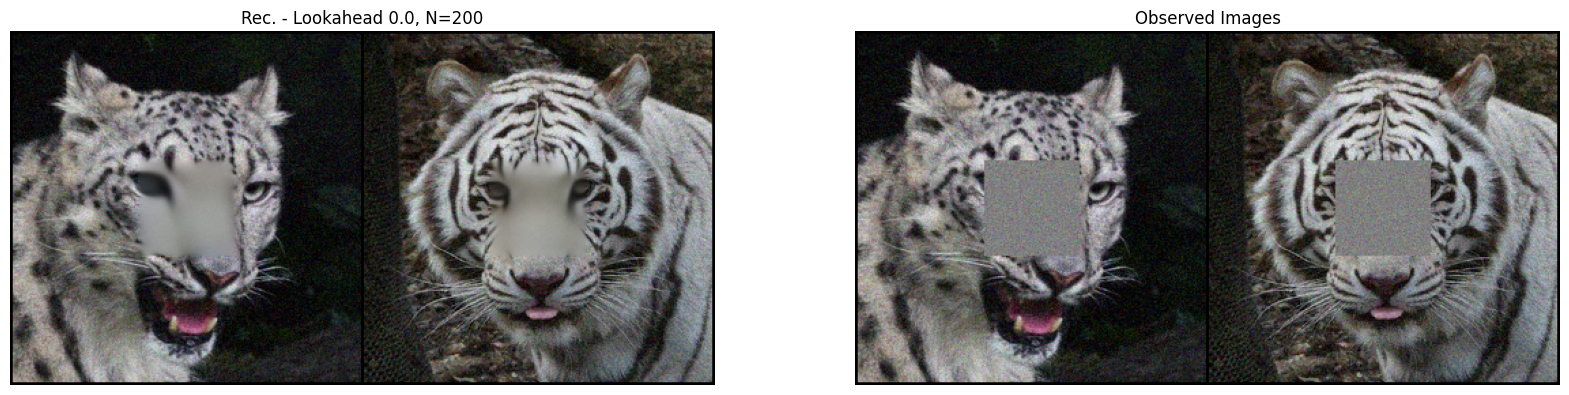

In [10]:
# Compute PSNR
def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # Images converted to [0, 1] before PSNR
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item(), mse.item()

seed = 200
# N = 10  # same for everyone
noise_std = 1e-1

torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    # box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    box_size_i = 70
    # test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.9, device=device))
    test_mask.append(generate_random_box_mask(1, 1, img_size, img_size, min_box_size=box_size_i, max_box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]
if data == 'cifar10' or data == 'celeba':
    # Repeat the mask across 3 channels for CIFAR10
    test_mask = test_mask.repeat(1, 3, 1, 1)

# Fix noisy image once
noisy_img = test_mask * img.to(device) + noise_std * torch.randn_like(img.to(device))
alpha = 0.05  # Exponent in the learning rate

with torch.no_grad():
    results = {}
    results_lpips = {}
    x_intermediate = {}
    N_steps = 200
    for N in [N_steps]:

        for lookahead in [0.0]:
            # fig, ax = plt.subplots()
            torch.manual_seed(seed)
            np.random.seed(seed)
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            x = torch.zeros((batch_size, 3, img_size, img_size)).to(device)
            # x = torch.randn((batch_size, 1, img_size, img_size)).to(device)
            
            for i in range(N):
                t = torch.ones(len(x), device=device) * (i / N)
                t_target = torch.clamp(t + lookahead, max=1.0)
                
                # Data fidelity
                lr_t =  (1 - t).view(-1, 1, 1, 1)**alpha
                z = x - lr_t * test_mask * (test_mask * x - noisy_img)

                # Interpolation
                # wit/h torch.no_grad():
                z_tilde = t.view(-1,1,1,1) * z + \
                    torch.randn_like(x) * (1 - t.view(-1,1,1,1))
                    
                # Denoising with lookahead
                # print(t)
                x = z_tilde + (1 - t.view(-1,1,1,1)) * \
                    net(z_tilde, t.view(-1,1,1,1), t_target.view(-1,1,1,1))

                # Plot the current image
                if i % 10 == 0 or i == N - 1:
                    x_intermediate[(N, lookahead, i)] = x.detach().cpu()
                    # clear_output(wait=True)
                    # ax.imshow(torch.clip((x[0].cpu()),
                    #         0, 1).permute(1, 2, 0), vmin=0, vmax=1)
                    # ax.axis('off')
                    # ax.set_title(
                    #     'Reconstructed image at time t={:4.2f}'.format((1 / N) * i))
                    # display(fig)

            # clear_output(wait=False)
                
            x_ = torch.clamp((x.detach() + 1)/2, 0, 1)
            psnr, mse = compute_psnr(x_, ((img + 1)/2).to(device))
            results[(N, lookahead)] = psnr
            print(f"N={N}, lookahead={lookahead:.1f} | PSNR={psnr:.2f}dB")
            print(f"N={N}, lookahead={lookahead:.1f} | MSE={mse:.5f}")
            with torch.no_grad():
                lpips_score = 0.0
                for idx in range(x.shape[0]):
                    lpips_score += loss_fn_alex(x[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
            results_lpips[(N, lookahead)] = lpips_score / x.shape[0]
            print(f"N={N}, lookahead={lookahead:.1f} | LPIPS={results_lpips[(N, lookahead)]:.4f}")

            plt.figure(figsize=(20, 20))
            plt.subplot(1, 2, 1)
            plt.title(f'Rec. - Lookahead {lookahead}, N={N}')
            plt.imshow(grid(((x[2:4].detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.title('Observed Images')
            plt.imshow(grid(((noisy_img[2:4] + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
            plt.axis('off')

In [ ]:
# Plot PSNR and LPIPS vs lookahead
N_steps = 100
lookahead_values = sorted(set(key[1] for key in results.keys()))
psnr_values = [results[(N_steps, lookahead)] for lookahead in lookahead_values]
lpips_values = [results_lpips[(N_steps, lookahead)] for lookahead in lookahead_values]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lookahead_values, psnr_values, 'o-', linewidth=2)
plt.xlabel('Lookahead $\\Delta s$')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Lookahead')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(lookahead_values, lpips_values, 'o-', linewidth=2)
plt.xlabel('Lookahead $\\Delta s$')
plt.ylabel('LPIPS')
plt.title('LPIPS vs Lookahead')
plt.grid()
plt.tight_layout()
plt.savefig('psnr_lpips_vs_lookahead-deblurring.pdf')
plt.show()

In [ ]:
s_values = [0.3, 0.5, 0.7]  # try multiple source times
delta_s_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
# clamp t = s + delta_s <= 1
M = 50

x1 = img.to(device)
fig, axes = plt.subplots(1, len(s_values), figsize=(14, 4))

for ax, s_val in zip(axes, s_values):
    mse_list = []

    with torch.no_grad():
        for delta_s in delta_s_values:
            t_val = min(s_val + delta_s, 1.0)
            # skip if no room for lookahead
            if t_val <= s_val:
                continue
            t_src = torch.full((batch_size,1,1,1), s_val, device=device)
            t_tgt = torch.full((batch_size,1,1,1), t_val, device=device)

            mse_accum = 0.0
            for _ in range(M):
                x0 = torch.randn_like(x1)
                # x_s is on the interpolant at time s
                xs = s_val * x1 + (1 - s_val) * x0
                v = net(xs, t_src, t_tgt)
                x1_hat = xs + (1 - s_val) * v
                mse_accum += ((x1_hat - x1) ** 2).mean().item()

            mse_list.append(mse_accum / M)
            print(f"s={s_val}, Δs={delta_s:.2f} | MSE={mse_accum/M:.5f}")

    ax.plot(delta_s_values[:len(mse_list)], mse_list, 'o-', linewidth=2)
    ax.set_xlabel('Lookahead $\\Delta s$')
    ax.set_ylabel('MSE')
    ax.set_title(f'$s = {s_val}$')
    ax.set_yscale('log')

plt.suptitle('Denoiser MSE vs lookahead $\\Delta s$ (Theorem 1)')
plt.tight_layout()
plt.savefig('denoiser_mse_vs_lookahead.pdf')
plt.show()

In [ ]:
# Given the dictionary x_intermediate, I want 3 plots: one for each lookahead, where each row has all the x_intermediate

for lookahead in [0.0, 0.5, 1.0]:
    plt.figure(figsize=(12, 8))
    for i, N in enumerate([100]):
        for j, step in enumerate(sorted([key[2] for key in x_intermediate.keys() if key[0] == N and key[1] == lookahead])):
            plt.subplot(len([100]), len(sorted([key[2] for key in x_intermediate.keys() if key[0] == N and key[1] == lookahead])), i*len(sorted([key[2] for key in x_intermediate.keys() if key[0] == N and key[1] == lookahead])) + j + 1)
            plt.title(f'N={N}, lookahead={lookahead}, step={step}')
            plt.imshow(grid(torch.clamp(x_intermediate[(N, lookahead, step)], 0, 1).permute(0,2,3,1)).squeeze())
            plt.axis('off')
    plt.tight_layout()
    plt.show()

## Deblurring

In [ ]:
# Compute PSNR
import PIL


def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # Images converted to [0, 1] before PSNR
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item(), mse.item()

seed = 30
# N = 10  # same for everyone
noise_std = 5e-2 #0.5e-1

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    # box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    box_size_i = 10
    test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.9, device=device))
    # test_mask.append(generate_random_box_mask(1, 1, img_size, img_size, min_box_size=box_size_i, max_box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]

test_mask = Blurkernel(blur_type='gaussian', kernel_size=61, std=3.0, device=device, channels=3).to(device)
# test_mask = SuperResolutionOperator(in_shape=(batch_size, 3, img_size, img_size), scale_factor=4, device=device)
# test_mask = MotionBlurOperator(kernel_size=31, intensity=0.3, device=device)
# test_mask = PhaseRetrievalOperator(device=device, oversample=4, resolution=img_size).to(device)
# test_mask = Decolorize(channels=3, device=device)
# Fix noisy image once
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# noisy_img = test_mask * img.to(device) + noise_std * torch.randn_like(img.to(device))

# import torchvision.transforms as v2
# image_path = '/home/nvidia/PnP-Flow/demo/example.jpg'
# clean_img = Image.open(image_path)

# # Define the transformation
# transform = v2.Compose([
#     v2.ToTensor(),
#     v2.Resize((img_size, img_size)),
#     v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
# ])
# # Apply the transformation
# img = transform(clean_img).unsqueeze(0).to(device)
# # print(img)
# batch_size = 1

noisy_img = test_mask(img.to(device)) 
noisy_img = noisy_img + noise_std * torch.randn_like(noisy_img)
alpha = 0.1  # Exponent in the learning rate

# with torch.no_grad():
results = {}
results_lpips = {}
result_images = {}
noisy_images = {}
noisy_images[('SR', 100, 0)] = noisy_img.detach().cpu()
deg = "PR"
for N in [100]:
    for lookahead in [0, 1.0]: #, 0.1, 0.3, 0.5, 1
        torch.manual_seed(seed)
        np.random.seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # x = torch.zeros((batch_size, 1, 32, 32)).to(device)
        x = torch.zeros((batch_size,3, img_size, img_size)).to(device)
        
        for i in range(N):
            t = torch.ones(len(x), device=device) * (i / N)
            t_target = torch.clamp(t + lookahead, max=1.0)
            
            # Data fidelity
            lr_t = (1 - t).view(-1,1,1,1)**alpha
            # z = x - lr_t * test_mask * (test_mask * x - noisy_img)

            x_leaf = x.detach().requires_grad_(True)
            residual = (noisy_img - test_mask(x_leaf))**2
            grad = torch.autograd.grad(residual.sum(), x_leaf)[0]
            z = x_leaf.detach() - lr_t * grad.detach()
            
            # Interpolation
            with torch.no_grad():
                z_tilde = t.view(-1,1,1,1) * z + \
                        torch.randn_like(x) * (1 - t.view(-1,1,1,1))
                
                # Denoising with lookahead
                x = z_tilde + (1 - t.view(-1,1,1,1)) * \
                    net(z_tilde, t.view(-1,1,1,1), t_target.view(-1,1,1,1))

            
        x_ = torch.clamp((x.detach() + 1)/2, 0, 1)
        psnr, mse = compute_psnr(x_, ((img + 1)/2).to(device))
        results[(deg, N, lookahead)] = psnr
        result_images[(deg, N, lookahead)] = x.detach().clone()
        print(f"N={N}, lookahead={lookahead:.1f} | PSNR={psnr:.2f}dB")
        print(f"N={N}, lookahead={lookahead:.1f} | MSE={mse:.5f}")
        with torch.no_grad():
            lpips_score = 0.0
            for idx in range(x.shape[0]):
                lpips_score += loss_fn_alex(x[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
        results_lpips[(deg, N, lookahead)] = lpips_score / x.shape[0]
        print(f"N={N}, lookahead={lookahead:.1f} | LPIPS={results_lpips[(deg, N, lookahead)]:.4f}")
        
        plt.figure(figsize=(50, 50))
        plt.subplot(1, 2, 1)
        plt.title(f'Rec. - Lookahead {lookahead}, N={N}')
        plt.imshow(grid(((x[0:1].detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Observed Images')
        plt.imshow(grid(((noisy_img[0:1] + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
        plt.axis('off')

        plt.savefig(f'reconstruction_lookahead_{lookahead}_N_{N}_deblurring.pdf')
        # plt.show()

# dps_result = dps_ode(noisy_img, img, test_mask, net, num_steps=100, alpha=0.05, device=device)
# psnr_dps, mse_dps = compute_psnr(dps_result, img.to(device))
# print(f"DPS ODE | PSNR={psnr_dps:.2f}dB")
# print(f"DPS ODE | MSE={mse_dps:.5f}")
# with torch.no_grad():
#     lpips_score_dps = 0.0
#     for idx in range(dps_result.shape[0]):
#         lpips_score_dps += loss_fn_alex(dps_result[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
# print(f"DPS ODE | LPIPS={lpips_score_dps / dps_result.shape[0]:.4f}")

# plt.figure(figsize=(8, 4))
# plt.subplot(1, 2, 1)
# plt.title(f'DPS ODE Result')
# plt.imshow(grid(dps_result[0:2].detach().permute(0,2,3,1).cpu()).squeeze())
# plt.axis('off')


In [ ]:
# PnP with proper Poisson noise model + Poisson NLL data-fidelity
import PIL


def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item(), mse.item()

seed = 30
peak = 30.0  # Poisson rate (photon count). Lower => noisier. Try 1, 5, 20, 50.

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    box_size_i = 10
    test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.9, device=device))
test_mask = torch.cat(test_mask, dim=0)

test_mask = Blurkernel(blur_type='gaussian', kernel_size=61, std=3.0, device=device, channels=3).to(device)
# test_mask = SuperResolutionOperator(in_shape=(batch_size, 3, img_size, img_size), scale_factor=4, device=device)
# test_mask = MotionBlurOperator(kernel_size=31, intensity=0.3, device=device)
# test_mask = PhaseRetrievalOperator(device=device, oversample=4, resolution=img_size).to(device)
# test_mask = Decolorize(channels=3, device=device)

torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Poisson observation: y ~ Poisson(peak * H(x)_01) / peak, mapped back to [-1, 1]
clean_meas = test_mask(img.to(device))
y01 = ((clean_meas + 1) / 2).clamp(0.0, 1.0)
noisy_img = (torch.poisson(peak * y01) / peak) * 2 - 1
alpha = 0.1

results = {}
results_lpips = {}
result_images = {}
noisy_images = {}
noisy_images[('Poisson', 100, 0)] = noisy_img.detach().cpu()
deg = "Poisson"

# Convert measurement to [0, 1] (working space for the Poisson NLL)
y01 = ((noisy_img + 1) / 2).clamp(min=0.0)

for N in [20, 50]:
    for lookahead in [0, 1.0]:
        torch.manual_seed(seed)
        np.random.seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        x = torch.zeros((batch_size, 3, img_size, img_size)).to(device)

        for i in range(N):
            t = torch.ones(len(x), device=device) * (i / N)
            t_target = torch.clamp(t + lookahead, max=1.0)

            # Data fidelity: Poisson NLL  L = sum(Hx - y * log(Hx))
            lr_t = (1 - t).view(-1, 1, 1, 1) ** alpha
            x_leaf = x.detach().requires_grad_(True)
            Hx = test_mask(x_leaf)
            Hx01 = ((Hx + 1) / 2).clamp(min=1e-9)
            fidelity = (Hx01 - y01 * torch.log(Hx01)).sum()
            grad = torch.autograd.grad(fidelity, x_leaf)[0]
            z = x_leaf.detach() - lr_t * grad.detach()

            with torch.no_grad():
                z_tilde = t.view(-1, 1, 1, 1) * z + \
                    torch.randn_like(x) * (1 - t.view(-1, 1, 1, 1))
                x = z_tilde + (1 - t.view(-1, 1, 1, 1)) * \
                    net(z_tilde, t.view(-1, 1, 1, 1), t_target.view(-1, 1, 1, 1))

        x_ = torch.clamp((x.detach() + 1) / 2, 0, 1)
        psnr, mse = compute_psnr(x_, ((img + 1) / 2).to(device))
        results[(deg, N, lookahead)] = psnr
        result_images[(deg, N, lookahead)] = x.detach().clone()
        print(f"N={N}, lookahead={lookahead:.1f} | PSNR={psnr:.2f}dB")
        print(f"N={N}, lookahead={lookahead:.1f} | MSE={mse:.5f}")
        with torch.no_grad():
            lpips_score = 0.0
            for idx in range(x.shape[0]):
                lpips_score += loss_fn_alex(x[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
        results_lpips[(deg, N, lookahead)] = lpips_score / x.shape[0]
        print(f"N={N}, lookahead={lookahead:.1f} | LPIPS={results_lpips[(deg, N, lookahead)]:.4f}")

        plt.figure(figsize=(50, 50))
        plt.subplot(1, 2, 1)
        plt.title(f'Rec. (Poisson) - Lookahead {lookahead}, peak={peak}, N={N}')
        plt.imshow(grid(((x[0:3].detach() + 1) / 2).clamp(0, 1).permute(0, 2, 3, 1).cpu()).squeeze())
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title(f'Observed (Poisson, peak={peak})')
        plt.imshow(grid(((noisy_img[0:3] + 1) / 2).clamp(0, 1).permute(0, 2, 3, 1).detach().cpu()).squeeze())
        plt.axis('off')

        plt.savefig(f'reconstruction_lookahead_{lookahead}_N_{N}_poisson_peak{int(peak)}.pdf')


In [ ]:
# test_mask = Blurkernel(blur_type='gaussian', kernel_size=61, std=3.0, device=device, channels=3).to(device)
# # test_mask = SuperResolutionOperator(in_shape=(batch_size, 3, img_size, img_size), scale_factor=4, device=device)

# noisy_img = test_mask(img.to(device)) 
# noisy_img = noisy_img + noise_std * torch.randn_like(noisy_img)
# alpha = 0.05  # Exponent in the learning rate

# # noisy_images = {}
# noisy_images[('deblurring', 100, 0)] = noisy_img.detach().cpu()

In [ ]:
# Plot PSNR vs LPIPS (colored points) + separate figure with image strip
import numpy as np
import matplotlib.pyplot as plt

N = list(set(key[1] for key in results.keys()))[0]
lookahead_values = sorted(set(key[2] for key in results.keys()))
psnr_values_SR  = [results[('SR', N, la)]       for la in lookahead_values]
lpips_values_SR = [results_lpips[('SR', N, la)] for la in lookahead_values]
psnr_values_deblurring  = [results[('deblurring', N, la)]       for la in lookahead_values]
lpips_values_deblurring = [results_lpips[('deblurring', N, la)] for la in lookahead_values]

colors = plt.cm.tab10.colors[:len(lookahead_values)]
n_imgs = len(lookahead_values)

# ── Figure 1: PSNR vs LPIPS curve ────────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(6, 5))
ax.plot(lpips_values_SR, psnr_values_SR, '-', linewidth=1.5, color='gray', zorder=1, label='SR x 4')
ax.plot(lpips_values_deblurring, psnr_values_deblurring, '--', linewidth=1.5, color='black', zorder=2, label='Deblurring')
for i, la in enumerate(lookahead_values):
    ax.scatter(lpips_values_SR[i], psnr_values_SR[i],
               color=colors[i], s=80, zorder=3, label=f'$\\Delta s={la}$',
               edgecolor='black', linewidth=1.5)
    ax.scatter(lpips_values_deblurring[i], psnr_values_deblurring[i],
               color=colors[i], s=80, zorder=3,
               marker='o', edgecolor='black', linewidth=1.5)
ax.set_xlabel('LPIPS (lower is better)', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title(f'PSNR vs LPIPS  (N={N})', fontsize=13)
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3)
fig1.tight_layout()
fig1.savefig('psnr_vs_lpips_curve.pdf', bbox_inches='tight')
fig1.show()

# ── Figure 2: image strip with colored borders for SR ────────────────────────────────
fig2, axes = plt.subplots(1, n_imgs+1, figsize=(3 * n_imgs, 3.5))
axes[0].imshow(((noisy_images[('SR', 100, 0)][0] + 1) / 2).clamp(0, 1).permute(1, 2, 0).cpu())
axes[0].set_xticks([])
axes[0].set_yticks([])
# axes[0].set_xlabel('Noisy input', fontsize=10)
for spine in axes[0].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(3)
for i, la in enumerate(lookahead_values):
    img_tensor = result_images[('SR', N, la)]
    img_np = ((img_tensor[0].detach().cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[i+1].imshow(img_np)
    axes[i+1].set_xticks([])
    axes[i+1].set_yticks([])
    # axes[i+1].set_xlabel(f'$\\Delta s={la}$', fontsize=10)

    for spine in axes[i+1].spines.values():
        spine.set_edgecolor(colors[i])
        spine.set_linewidth(3)

fig2.tight_layout()
fig2.savefig('psnr_vs_lpips_images-sr.pdf', bbox_inches='tight')
fig2.show()

# -- Figure 3: image strip with colored borders for deblurring ────────────────────────────────
fig3, axes = plt.subplots(1, n_imgs+1, figsize=(3 * n_imgs, 3.5))
axes[0].imshow(((noisy_images[('deblurring', 100, 0)][0] + 1) / 2).clamp(0, 1).permute(1, 2, 0).cpu())
axes[0].set_xticks([])
axes[0].set_yticks([])
# axes[0].set_xlabel('Noisy input', fontsize=10)
for spine in axes[0].spines.values():    
    spine.set_edgecolor('black')
    spine.set_linewidth(3)
for i, la in enumerate(lookahead_values):
    img_tensor = result_images[('deblurring', N, la)]
    img_np = ((img_tensor[0].detach().cpu() + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[i+1].imshow(img_np)
    axes[i+1].set_xticks([])
    axes[i+1].set_yticks([])
    # axes[i+1].set_xlabel(f'$\\Delta s={la}$', fontsize=10)

    for spine in axes[i+1].spines.values():
        spine.set_edgecolor(colors[i])
        spine.set_linewidth(3)
fig3.tight_layout()
fig3.savefig('psnr_vs_lpips_images_deblurring.pdf', bbox_inches='tight')
fig3.show()

## Ablation on number of ODE steps

In [ ]:
def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # Images converted to [0, 1] before PSNR
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

seed = 30
# N = 10  # same for everyone
noise_std = 1e-2

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    # box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    box_size_i = 30
    # test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.8, device=device))
    test_mask.append(generate_random_box_mask(1, 1, img_size, img_size, min_box_size=box_size_i, max_box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]
if data == 'cifar10' or data == 'celeba':
    # Repeat the mask across 3 channels for CIFAR10
    test_mask = test_mask.repeat(1, 3, 1, 1)

test_mask = Blurkernel(blur_type='gaussian', kernel_size=5, std=3.0, device=device, channels=3).to(device)
# test_mask = SuperResolutionOperator(in_shape=(batch_size, 3, img_size, img_size), scale_factor=4, device=device)

# Fix noisy image once
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# noisy_img = test_mask * img.to(device) + noise_std * torch.randn_like(img.to(device))
noisy_img = test_mask(img.to(device)) 
noisy_img = noisy_img + noise_std * torch.randn_like(noisy_img)
alpha = 0.05 #0.05  # Exponent in the learning rate

# with torch.no_grad():
results = {}
results_lpips = {}
for N in [100]:
    for num_ode_steps in [1, 3, 7]:
        torch.manual_seed(seed)
        np.random.seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # x = torch.zeros((batch_size, 1, 32, 32)).to(device)
        # Initialize x as pure noise or a starting guessx
        x = torch.zeros((batch_size, 3, img_size, img_size)).to(device) 

        # Outer PnP Loop (e.g., N steps total)
        for i in range(N):
            t_val = i / N
            
            # --- 1. Gradient Step (Data Fidelity on CLEAN space) ---
            x_leaf = x.detach().requires_grad_(True)
            residual = (noisy_img - test_mask(x_leaf)).pow(2).sum()
            # residual = (noisy_img - test_mask * x_leaf).pow(2).sum()
            grad = torch.autograd.grad(residual, x_leaf)[0]
            
            lr_t = (1 - t_val)**alpha # or your chosen schedule
            z = x_leaf.detach() - lr_t * grad.detach()

            # lr_t = (1 - t_val)**alpha # or your chosen schedule
            # z = x - lr_t * test_mask * (test_mask * x - noisy_img)
            
            # --- 2. Interpolation Step (Push back to time t) ---
            noise = torch.randn_like(z)
            z_tilde = (1 - t_val) * noise + t_val * z
            
            # --- 3. Multi-Step Lookahead Denoising (The D_t Operator) ---
            # We integrate from tau = t_val up to 1.0
            y_curr = z_tilde
            tau = t_val
            
            with torch.no_grad():
                # Calculate the exact step size needed to reach 1.0 in K steps
                # step_size = (1.0 - t_val) / num_ode_steps
                
                # for k in range(num_ode_steps):
                #     tau_next = min(tau + step_size, 1.0)
                    
                #     tau_r = torch.full((len(x),1,1,1), tau, device=device)
                #     tau_t = torch.full((len(x),1,1,1), tau_next, device=device)
                    
                #     # net outputs velocity v_{tau, tau_next}
                #     v = net(y_curr, tau_r, tau_t)
                    
                #     # Plain Euler step — correct for velocity field output
                #     y_curr = y_curr + (tau_next - tau) * v
                    
                #     tau = tau_next
                t_values = torch.linspace(t_val, 1.0, num_ode_steps + 1, device=device)

                y_curr = z_tilde
                for k in range(num_ode_steps):
                    tau_r = t_values[k].view(1,1,1,1).expand(len(x),-1,-1,-1)
                    tau_t = t_values[k+1].view(1,1,1,1).expand(len(x),-1,-1,-1)
                    
                    v = net(y_curr, tau_r, tau_t)
                    y_curr = y_curr + (tau_t - tau_r) * v
                    
            # The output of the inner loop is our new clean estimate
            x = y_curr
        
        x = x.clamp(-1, 1)
        psnr = compute_psnr((x + 1) / 2, (img.to(device) + 1) / 2)
        results[(N, num_ode_steps)] = psnr
        print(f"N={N}, Num ODE Steps={num_ode_steps} | PSNR={psnr:.2f}dB")
        with torch.no_grad():
            lpips_score = 0.0
            for idx in range(x.shape[0]):
                lpips_score += loss_fn_alex(x[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
        results_lpips[(N, num_ode_steps)] = lpips_score / x.shape[0]
        print(f"N={N}, Num ODE Steps={num_ode_steps} | LPIPS={results_lpips[(N, num_ode_steps)]:.4f}")

        plt.figure(figsize=(12, 8))
        plt.subplot(1, 2, 1)
        plt.title(f'Rec. - Num ODE Steps {num_ode_steps}, N={N}')
        plt.imshow(grid(((x.detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Observed Images')
        plt.imshow(grid(((noisy_img + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
        plt.axis('off')



## Gaussian denoising

In [ ]:
# Compute PSNR
import PIL


def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # Images converted to [0, 1] before PSNR
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item(), mse.item()

seed = 30
noisy_img = img.to(device)
alpha = 0.3  # Exponent in the learning rate
noise_std = alpha
noisy_img = noisy_img + noise_std * torch.randn_like(noisy_img)

# with torch.no_grad():
results = {}
results_lpips = {}
N = 100
for lookahead in [0.0, 0.1, 0.3, 0.5, 1.0]:
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # x = torch.zeros((batch_size, 1, 32, 32)).to(device)
    x = torch.zeros((batch_size,3, img_size, img_size)).to(device)
    
    t = torch.ones(len(x), device=device) * (1 - alpha)
    t_target = torch.clamp(t + lookahead, max=1.0)

    # Interpolation
    with torch.no_grad():            
        # Denoising with lookahead
        x = noisy_img + (1 - t.view(-1,1,1,1)) * \
            net(noisy_img, t.view(-1,1,1,1), t_target.view(-1,1,1,1))

        
    x_ = torch.clamp((x.detach() + 1)/2, 0, 1)
    psnr, mse = compute_psnr(x_, ((img + 1)/2).to(device))
    results[(N, lookahead)] = psnr
    print(f"N={N}, lookahead={lookahead:.1f} | PSNR={psnr:.2f}dB")
    print(f"N={N}, lookahead={lookahead:.1f} | MSE={mse:.5f}")
    with torch.no_grad():
        lpips_score = 0.0
        for idx in range(x.shape[0]):
            lpips_score += loss_fn_alex(x_[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
    results_lpips[(N, lookahead)] = lpips_score / x.shape[0]
    print(f"N={N}, lookahead={lookahead:.1f} | LPIPS={results_lpips[(N, lookahead)]:.4f}")
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title(f'Rec. - Lookahead {lookahead}, N={N}')
    plt.imshow(grid(((x[0:2].detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Observed Images')
    plt.imshow(grid(((noisy_img[0:2] + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
    plt.axis('off')

    # plt.savefig(f'reconstruction_lookahead_{lookahead}_N_{N}_deblurring.pdf')




In [ ]:

# Compute PSNR
import PIL


def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # Images converted to [0, 1] before PSNR
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item(), mse.item()

seed = 30
N = 100
# noisy_img = img.to(device)
alpha = 0.3
s_val = 1.0 - alpha 

clean_img = img.to(device)
eps = torch.randn_like(clean_img)

# EXACT Interpolant: x_s = alpha * noise + (1 - alpha) * clean_img
noisy_img = (alpha * eps) + (s_val * clean_img)

results = {}
results_lpips = {}
for lookahead in [0.0, 0.1, 0.3, 0.5, 1.0]:
    # s is our starting 'time' (closeness to clean data)
    s = torch.ones(len(noisy_img), device=device) * s_val
    # t is our 'lookahead' target
    t_target = torch.clamp(s + lookahead, max=1.0)

    with torch.no_grad():            
        # Equation: D_{s,t}(x) = x + (1-s) * v_{s,t}(x, s, t)
        # Note: (1-s) is exactly alpha. 
        # This constant pulls the velocity all the way to x_1.
        v_pred = net(noisy_img, s.view(-1,1,1,1), t_target.view(-1,1,1,1))
        x = noisy_img + (1.0 - s.view(-1,1,1,1)) * v_pred
        
    # EVALUATION
    x_= torch.clamp((x + 1)/2, 0, 1)
    psnr, mse = compute_psnr(x_, ((img + 1)/2).to(device))
    results[(N, lookahead)] = psnr
    print(f"N={N}, lookahead={lookahead:.1f} | PSNR={psnr:.2f}dB")
    print(f"N={N}, lookahead={lookahead:.1f} | MSE={mse:.5f}")
    with torch.no_grad():
        lpips_score = 0.0
        for idx in range(x.shape[0]):
            lpips_score += loss_fn_alex(x[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
    results_lpips[(N, lookahead)] = lpips_score / x.shape[0]
    print(f"N={N}, lookahead={lookahead:.1f} | LPIPS={results_lpips[(N, lookahead)]:.4f}")
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title(f'Rec. - Lookahead {lookahead}, N={N}')
    plt.imshow(grid(((x[0:2].detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Observed Images')
    plt.imshow(grid(((noisy_img[0:2] + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
    plt.axis('off')

    # plt.savefig(f'reconstruction_lookahead_{lookahead}_N_{N}_deblurring.pdf')

In [ ]:
# %% [markdown]
# # P-D Curve Evaluation for Flow Map Denoisers
# 
# This notebook evaluates the average denoiser $D_{s,t}(\mathbf{x}) = \mathbf{x} + (1-s) v_{s,t}(\mathbf{x})$
# across different lookahead values and plots the perception-distortion curve.

# %% 
# ============================================================
# 1. Setup (adapt these to your environment)
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import lpips

device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
loss_fn_alex = lpips.LPIPS(net='alex').to(device)

# TODO: Load your model and data here
# net = ...
# img = ...  # batch of clean images in [-1, 1], shape (B, C, H, W)

# %%
# ============================================================
# 2. Evaluate P-D curve
# ============================================================

seed = 30
torch.manual_seed(seed)

alpha = 0.3
s_val = 1.0 - alpha  # = 0.7

clean_img = img.to(device)
eps = torch.randn_like(clean_img).to(device)
noisy_img = alpha * eps + s_val * clean_img

# Fine sweep of lookahead values
lookaheads = np.concatenate([
    np.arange(0.0, 0.05, 0.005),   # very fine near MMSE
    np.arange(0.05, 0.15, 0.01),   # fine
    np.arange(0.15, 0.301, 0.025), # moderate (max is 1 - s_val = 0.3)
])
lookaheads = np.unique(np.clip(lookaheads, 0, 1.0 - s_val))

results_psnr = []
results_mse = []
results_lpips = []
results_lookahead = []

for lookahead in lookaheads:
    s = torch.ones(len(clean_img), device=device) * s_val
    t_target = torch.clamp(s + lookahead, max=1.0).to(device)

    with torch.no_grad():
        v_pred = net(noisy_img, s.view(-1,1,1,1), t_target.view(-1,1,1,1))
        x = noisy_img + (1.0 - s.view(-1,1,1,1)) * v_pred

    # Map to [0, 1]
    x_ = torch.clamp((x + 1) / 2, 0, 1)
    clean_01 = ((clean_img + 1) / 2).to(device)

    # PSNR / MSE
    mse = F.mse_loss(x_, clean_01).item()
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * np.log10(1.0 / np.sqrt(mse))

    # LPIPS
    with torch.no_grad():
        lpips_score = 0.0
        for idx in range(x.shape[0]):
            lpips_score += loss_fn_alex(x[idx:idx+1], clean_img[idx:idx+1]).item()
        lpips_score /= x.shape[0]

    results_lookahead.append(float(lookahead))
    results_psnr.append(psnr)
    results_mse.append(mse)
    results_lpips.append(lpips_score)

    print(f"lookahead={lookahead:.3f} | PSNR={psnr:.2f}dB | "
          f"MSE={mse:.5f} | LPIPS={lpips_score:.4f}")

# Convert to arrays
results_lookahead = np.array(results_lookahead)
results_psnr = np.array(results_psnr)
results_mse = np.array(results_mse)
results_lpips = np.array(results_lpips)

# %%
# ============================================================
# 3. Plot P-D curve (main figure for paper)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: P-D curve (LPIPS vs PSNR)
ax = axes[0]
sc = ax.scatter(results_lpips, results_psnr, c=results_lookahead, 
                cmap='viridis', s=60, edgecolors='k', linewidths=0.5, zorder=3)
ax.plot(results_lpips, results_psnr, '-', color='gray', alpha=0.4, zorder=2)
ax.set_xlabel('Perception (LPIPS) ← better', fontsize=12)
ax.set_ylabel('PSNR (dB) ↑ better', fontsize=12)
ax.set_title('P-D tradeoff curve', fontsize=13)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Lookahead Δt', fontsize=10)
ax.grid(True, alpha=0.3)
# Annotate endpoints
ax.annotate('MMSE\n(t=s)', (results_lpips[0], results_psnr[0]),
            textcoords="offset points", xytext=(10, -15), fontsize=9,
            color='#534AB7', fontweight='bold')
ax.annotate('t→1', (results_lpips[-1], results_psnr[-1]),
            textcoords="offset points", xytext=(10, 5), fontsize=9,
            color='#D85A30', fontweight='bold')

# Panel 2: PSNR vs lookahead
ax = axes[1]
ax.plot(results_lookahead, results_psnr, 'o-', color='#0F6E56', markersize=4)
ax.set_xlabel('Lookahead Δt', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('Distortion vs lookahead', fontsize=13)
ax.grid(True, alpha=0.3)

# Panel 3: LPIPS vs lookahead
ax = axes[2]
ax.plot(results_lookahead, results_lpips, 's-', color='#D85A30', markersize=4)
ax.set_xlabel('Lookahead Δt', fontsize=12)
ax.set_ylabel('LPIPS', fontsize=12)
ax.set_title('Perception vs lookahead', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pd_curve_main.pdf', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nD* (MMSE distortion, MSE): {results_mse[0]:.5f}")
print(f"P* (MMSE perception, LPIPS): {results_lpips[0]:.4f}")

# %%
# ============================================================
# 4. Plot MSE vs LPIPS (connects to Freirich theory)
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4.5))
sc = ax.scatter(results_lpips, results_mse, c=results_lookahead,
                cmap='viridis', s=60, edgecolors='k', linewidths=0.5, zorder=3)
ax.plot(results_lpips, results_mse, '-', color='gray', alpha=0.4, zorder=2)
ax.set_xlabel('Perception (LPIPS)', fontsize=12)
ax.set_ylabel('Distortion (MSE)', fontsize=12)
ax.set_title('P-D tradeoff (MSE scale)', fontsize=13)
ax.axhline(y=results_mse[0], color='gray', linestyle=':', alpha=0.5)
# ax.text(results_lpips[-1], results_mse[0] + 0.001, 
#         f'D* = {results_mse[0]:.4f}', fontsize=9, color='gray')
plt.colorbar(sc, ax=ax, label='Lookahead Δt')
ax.grid(True, alpha=0.3)
# plt.tight_layout()
plt.savefig('pd_curve_mse.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# 5. Visual comparison across lookaheads
# ============================================================

n_show = 4  # number of images to show
vis_lookaheads = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
n_la = len(vis_lookaheads)

fig, axes = plt.subplots(n_show, n_la + 2, figsize=(2.2*(n_la+2), 2.2*n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    # Clean
    axes[i, 0].imshow(((clean_img[i] + 1)/2).clamp(0,1).permute(1,2,0).cpu())
    if i == 0: axes[i, 0].set_title('Clean', fontsize=10)
    axes[i, 0].axis('off')

    # Noisy
    axes[i, 1].imshow(((noisy_img[i] + 1)/2).clamp(0,1).permute(1,2,0).cpu())
    if i == 0: axes[i, 1].set_title('Noisy', fontsize=10)
    axes[i, 1].axis('off')

    # Reconstructions
    for j, la in enumerate(vis_lookaheads):
        s = torch.ones(1, device=device) * s_val
        t_target = torch.clamp(s + la, max=1.0)
        with torch.no_grad():
            v_pred = net(noisy_img[i:i+1], s.view(-1,1,1,1), t_target.view(-1,1,1,1))
            x_hat = noisy_img[i:i+1] + (1.0 - s.view(-1,1,1,1)) * v_pred

        axes[i, j+2].imshow(((x_hat[0]+1)/2).clamp(0,1).permute(1,2,0).cpu())
        if i == 0:
            if la == 0.0:
                axes[i, j+2].set_title('MMSE', fontsize=10)
            else:
                axes[i, j+2].set_title(f'Δt={la:.2f}', fontsize=10)
        axes[i, j+2].axis('off')

plt.tight_layout()
plt.savefig('visual_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# 6. Summary table
# ============================================================

print("\n" + "="*65)
print(f"{'Lookahead':>10} | {'PSNR (dB)':>10} | {'MSE':>10} | {'LPIPS':>10}")
print("-"*65)
for i in range(len(results_lookahead)):
    print(f"{results_lookahead[i]:10.3f} | {results_psnr[i]:10.2f} | "
          f"{results_mse[i]:10.5f} | {results_lpips[i]:10.4f}")
print("="*65)

# %%
# ============================================================
# 7. (Optional) Multiple noise levels
# ============================================================
# Uncomment to run the P-D curve at different noise levels

# all_results = {}
# for alpha in [0.1, 0.2, 0.3, 0.5]:
#     s_val = 1.0 - alpha
#     print(f"\n=== alpha={alpha}, s={s_val} ===")
#     
#     torch.manual_seed(seed)
#     eps = torch.randn_like(clean_img)
#     noisy_img = alpha * eps + s_val * clean_img
#     
#     max_la = 1.0 - s_val
#     lookaheads = np.linspace(0, max_la, 20)
#     
#     res = {'la': [], 'psnr': [], 'lpips': []}
#     for la in lookaheads:
#         s = torch.ones(len(clean_img), device=device) * s_val
#         t_target = torch.clamp(s + la, max=1.0)
#         with torch.no_grad():
#             v_pred = net(noisy_img, s.view(-1,1,1,1), t_target.view(-1,1,1,1))
#             x = noisy_img + (1.0 - s.view(-1,1,1,1)) * v_pred
#         x_ = torch.clamp((x + 1) / 2, 0, 1)
#         clean_01 = ((clean_img + 1) / 2).to(device)
#         mse = F.mse_loss(x_, clean_01).item()
#         psnr = 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else float('inf')
#         with torch.no_grad():
#             lp = sum(loss_fn_alex(x_[i:i+1], clean_01[i:i+1]).item() 
#                      for i in range(x.shape[0])) / x.shape[0]
#         res['la'].append(la)
#         res['psnr'].append(psnr)
#         res['lpips'].append(lp)
#         print(f"  la={la:.3f} | PSNR={psnr:.2f} | LPIPS={lp:.4f}")
#     all_results[alpha] = res
# 
# # Plot all noise levels on one figure
# fig, ax = plt.subplots(figsize=(7, 5))
# for alpha, res in all_results.items():
#     ax.plot(res['lpips'], res['psnr'], 'o-', markersize=4,
#             label=f'α={alpha} (s={1-alpha})')
# ax.set_xlabel('LPIPS ← better')
# ax.set_ylabel('PSNR (dB) ↑ better')
# ax.set_title('P-D curves at different noise levels')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig('pd_curves_multi_noise.pdf', bbox_inches='tight')
# plt.show()

In [ ]:
# %%
# ============================================================
# 5. Visual comparison across lookaheads
# ============================================================

n_show = 4  # number of images to show
vis_lookaheads = [0.0, 0.1, 0.2, 0.3, 0.7]
n_la = len(vis_lookaheads)

fig, axes = plt.subplots(n_show, n_la + 2, figsize=(2.2*(n_la+2), 2.2*n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    # Clean
    axes[i, 0].imshow(((clean_img[i] + 1)/2).clamp(0,1).permute(1,2,0).cpu())
    if i == 0: axes[i, 0].set_title('Clean', fontsize=17)
    axes[i, 0].axis('off')

    # Noisy
    axes[i, 1].imshow(((noisy_img[i] + 1)/2).clamp(0,1).permute(1,2,0).cpu())
    if i == 0: axes[i, 1].set_title(r'Noisy ($\alpha=0.3$)', fontsize=17)
    axes[i, 1].axis('off')

    # Reconstructions
    for j, la in enumerate(vis_lookaheads):
        s = torch.ones(1, device=device) * s_val
        t_target = torch.clamp(s + la, max=1.0)
        with torch.no_grad():
            v_pred = net(noisy_img[i:i+1], s.view(-1,1,1,1), t_target.view(-1,1,1,1))
            x_hat = noisy_img[i:i+1] + (1.0 - s.view(-1,1,1,1)) * v_pred

        axes[i, j+2].imshow(((x_hat[0]+1)/2).clamp(0,1).permute(1,2,0).cpu())
        if i == 0:
            if la == 0.0:
                axes[i, j+2].set_title(f'MMSE ($t = s$)', fontsize=17)
            else:
                axes[i, j+2].set_title(f't= s+{la:.2f}', fontsize=17)
        axes[i, j+2].axis('off')

plt.tight_layout()
plt.savefig('visual_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# %% [markdown]
# # P-D Curves at Multiple Noise Levels
# 
# Runs the P-D sweep at several noise levels (alpha values) and produces
# a single overlay figure for the paper.

# %%
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import lpips

device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
loss_fn_alex = lpips.LPIPS(net='alex').to(device)

# TODO: Load your model and data
# net = ...
# img = ...  # clean images in [-1, 1], shape (B, C, H, W)

# %%
# ============================================================
# 1. Run P-D sweep at multiple noise levels
# ============================================================

seed = 30
alphas = [0.1, 0.3, 0.5, 0.7]  # noise levels (alpha = 1 - s)
n_points = 30  # points per curve

clean_img = img.to(device)
all_results = {}

for alpha in alphas:
    s_val = 1.0 - alpha
    max_la = 1.0 - s_val  # = alpha
    
    torch.manual_seed(seed)
    eps = torch.randn_like(clean_img)
    noisy_img = alpha * eps + s_val * clean_img
    
    lookaheads = np.linspace(0, max_la, n_points)
    
    res = {'lookahead': [], 'psnr': [], 'mse': [], 'lpips': []}
    
    print(f"\n=== alpha={alpha}, s={s_val}, max lookahead={max_la:.2f} ===")
    for la in lookaheads:
        s = torch.ones(len(clean_img), device=device) * s_val
        t_target = torch.clamp(s + la, max=1.0)
        
        with torch.no_grad():
            v_pred = net(noisy_img, s.view(-1,1,1,1), t_target.view(-1,1,1,1))
            x = noisy_img + (1.0 - s.view(-1,1,1,1)) * v_pred
        
        x_ = torch.clamp((x + 1) / 2, 0, 1)
        clean_01 = ((clean_img + 1) / 2).to(device)
        
        mse = F.mse_loss(x_, clean_01).item()
        psnr = 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else float('inf')
        
        with torch.no_grad():
            lp = sum(loss_fn_alex(x[i:i+1], clean_img[i:i+1]).item()
                     for i in range(x.shape[0])) / x.shape[0]
        
        res['lookahead'].append(float(la))
        res['psnr'].append(psnr)
        res['mse'].append(mse)
        res['lpips'].append(lp)
        print(f"  Δt={la:.3f} | PSNR={psnr:.2f} | MSE={mse:.5f} | LPIPS={lp:.4f}")
    
    all_results[alpha] = res

# %%
# ============================================================
# 2. Paper figure: overlaid P-D curves (PSNR vs LPIPS)
# ============================================================

colors = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5']
markers = ['o', 's', 'D', '^']

fig, ax = plt.subplots(figsize=(7, 5))

for i, (alpha, res) in enumerate(all_results.items()):
    lpips_arr = np.array(res['lpips'])
    psnr_arr = np.array(res['psnr'])
    
    ax.plot(lpips_arr, psnr_arr, '-', color=colors[i], alpha=0.4, linewidth=1.5)
    # Subsample markers to avoid clutter
    step = max(1, len(lpips_arr) // 10)
    ax.plot(lpips_arr[::step], psnr_arr[::step], markers[i],
            color=colors[i], markersize=6, markeredgecolor='k',
            markeredgewidth=0.5, label=f'$\\alpha={alpha}$ ($s={1-alpha:.1f}$)')
    
    # Mark MMSE endpoint
    ax.plot(lpips_arr[0], psnr_arr[0], markers[i], color=colors[i],
            markersize=9, markeredgecolor='k', markeredgewidth=1.0, zorder=5)
    # Mark t->1 endpoint
    ax.plot(lpips_arr[-1], psnr_arr[-1], markers[i], color=colors[i],
            markersize=9, markeredgecolor='k', markeredgewidth=1.0, zorder=5)

ax.set_xlabel('Perception (LPIPS) $\\leftarrow$ better', fontsize=13)
ax.set_ylabel('PSNR (dB) $\\uparrow$ better', fontsize=13)
ax.set_title('P-D tradeoff at different noise levels', fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pd_curves_multi_noise.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# 3. Paper figure: overlaid P-D curves (MSE vs LPIPS)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

for i, (alpha, res) in enumerate(all_results.items()):
    lpips_arr = np.array(res['lpips'])
    mse_arr = np.array(res['mse'])
    
    ax.plot(lpips_arr, mse_arr, '-', color=colors[i], alpha=0.4, linewidth=1.5)
    step = max(1, len(lpips_arr) // 10)
    ax.plot(lpips_arr[::step], mse_arr[::step], markers[i],
            color=colors[i], markersize=6, markeredgecolor='k',
            markeredgewidth=0.5, label=f'$\\alpha={alpha}$')
    
    # D* reference line
    ax.axhline(y=mse_arr[0], color=colors[i], linestyle=':', alpha=0.3)

ax.set_xlabel('Perception (LPIPS) $\\leftarrow$ better', fontsize=13)
ax.set_ylabel('Distortion (MSE)', fontsize=13)
ax.set_title('P-D tradeoff at different noise levels (MSE)', fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pd_curves_multi_noise_mse.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# 4. Paper figure: PSNR and LPIPS vs lookahead (all noise levels)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (alpha, res) in enumerate(all_results.items()):
    la_arr = np.array(res['lookahead'])
    psnr_arr = np.array(res['psnr'])
    lpips_arr = np.array(res['lpips'])
    
    # Normalize lookahead to [0, 1] for comparison across noise levels
    la_norm = la_arr / alpha  # now 0 = MMSE, 1 = t->1
    
    ax1.plot(la_norm, psnr_arr, '-'+markers[i], color=colors[i],
             markersize=4, markevery=3, label=f'$\\alpha={alpha}$')
    ax2.plot(la_norm, lpips_arr, '-'+markers[i], color=colors[i],
             markersize=4, markevery=3, label=f'$\\alpha={alpha}$')

ax1.set_xlabel('Normalized lookahead $\\Delta t / \\alpha$', fontsize=12)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.set_title('Distortion vs normalized lookahead', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Normalized lookahead $\\Delta t / \\alpha$', fontsize=12)
ax2.set_ylabel('LPIPS', fontsize=12)
ax2.set_title('Perception vs normalized lookahead', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pd_vs_lookahead_multi_noise.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# 5. Summary table
# ============================================================

print("\n" + "="*75)
print(f"{'alpha':>6} | {'s':>4} | {'PSNR(MMSE)':>11} | {'PSNR(t=1)':>10} | "
      f"{'LPIPS(MMSE)':>12} | {'LPIPS(t=1)':>11}")
print("-"*75)
for alpha, res in all_results.items():
    print(f"{alpha:6.1f} | {1-alpha:4.1f} | {res['psnr'][0]:11.2f} | "
          f"{res['psnr'][-1]:10.2f} | {res['lpips'][0]:12.4f} | "
          f"{res['lpips'][-1]:11.4f}")
print("="*75)
print("\nPSNR drop (MMSE → t=1):")
for alpha, res in all_results.items():
    drop = res['psnr'][0] - res['psnr'][-1]
    lpips_gain = res['lpips'][0] - res['lpips'][-1]
    print(f"  alpha={alpha}: ΔPSNR = {drop:.2f} dB, ΔLPIPS = {lpips_gain:.4f}")

## Variance

In [ ]:
# %% [markdown]
# # Variance Analysis: Total Variance Decomposition
#
# The law of total variance guarantees:
#   Var(x1) = Var(E[x1|xs]) + E[Var(x1|xs)]
# 
# So Var(D_s(xs)) = Var(E[x1|xs]) < Var(x1), i.e., the MMSE estimator
# must have lower variance than the true data. As lookahead increases,
# the average denoiser restores this missing variance.
#
# This is a verifiable, distribution-free fact that explains WHY
# the P-D traversal works.

# %%
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import lpips

device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
loss_fn_alex = lpips.LPIPS(net='alex').to(device)

# TODO: Load your model and data
# net = ...
# img = ...  # clean images in [-1, 1]

# %%
# ============================================================
# Compute variance of reconstructions at each lookahead
# ============================================================

seed = 30
alphas = [0.1, 0.3, 0.5, 0.7]
n_points = 25

clean_img = img.to(device)
clean_01 = ((clean_img + 1) / 2).clamp(0, 1)

# Variance of clean data (per channel, then average)
var_clean = clean_01.var(dim=0).mean().item()
print(f"Var(x1) = {var_clean:.6f}")

all_results = {}

for alpha in alphas:
    s_val = 1.0 - alpha
    max_la = alpha
    
    torch.manual_seed(seed)
    eps = torch.randn_like(clean_img)
    noisy_img = alpha * eps + s_val * clean_img
    
    lookaheads = np.linspace(0, max_la, n_points)
    
    res = {'lookahead': [], 'var': [], 'var_ratio': [],
           'psnr': [], 'lpips': [], 'mse': []}
    
    print(f"\n=== alpha={alpha} ===")
    for la in lookaheads:
        s = torch.ones(len(clean_img), device=device) * s_val
        t_target = torch.clamp(s + la, max=1.0)
        
        with torch.no_grad():
            v_pred = net(noisy_img, s.view(-1,1,1,1), t_target.view(-1,1,1,1))
            x = noisy_img + (1.0 - s.view(-1,1,1,1)) * v_pred
        
        x_ = torch.clamp((x + 1) / 2, 0, 1)
        
        # Variance of output
        var_out = x_.var(dim=0).mean().item()
        var_ratio = var_out / var_clean
        
        # MSE, PSNR
        mse = F.mse_loss(x_, clean_01).item()
        psnr = 20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else float('inf')
        
        # LPIPS
        with torch.no_grad():
            lp = sum(loss_fn_alex(x[i:i+1], clean_img[i:i+1]).item()
                     for i in range(x.shape[0])) / x.shape[0]
        
        res['lookahead'].append(float(la))
        res['var'].append(var_out)
        res['var_ratio'].append(var_ratio)
        res['psnr'].append(psnr)
        res['lpips'].append(lp)
        res['mse'].append(mse)
        
        print(f"  Δt={la:.3f} | Var={var_out:.6f} | "
              f"Var/Var(x1)={var_ratio:.4f} | PSNR={psnr:.2f} | LPIPS={lp:.4f}")
    
    all_results[alpha] = res

# %%
# ============================================================
# Figure: Variance ratio vs lookahead
# ============================================================

colors = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5']
markers = ['o', 's', 'D', '^']

fig, ax = plt.subplots(figsize=(7, 5))

for i, (alpha, res) in enumerate(all_results.items()):
    la_norm = np.array(res['lookahead']) / alpha
    ax.plot(la_norm, res['var_ratio'], '-'+markers[i], color=colors[i],
            markersize=5, markevery=3, label=f'$\\alpha={alpha}$')

ax.axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5,
           label='$\\mathrm{Var}(x_1)$')
ax.set_xlabel('Normalized lookahead $\\Delta t / \\alpha$', fontsize=13)
ax.set_ylabel('$\\mathrm{Var}(D_{s,t}) \\,/\\, \\mathrm{Var}(x_1)$', fontsize=13)
ax.set_title('Variance restoration via lookahead', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('variance_vs_lookahead.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# Figure: Variance ratio vs LPIPS (direct connection)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

for i, (alpha, res) in enumerate(all_results.items()):
    ax.plot(res['lpips'], res['var_ratio'], '-'+markers[i], color=colors[i],
            markersize=5, markevery=3, label=f'$\\alpha={alpha}$')

ax.axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Perception (LPIPS) $\\leftarrow$ better', fontsize=13)
ax.set_ylabel('$\\mathrm{Var}(D_{s,t}) \\,/\\, \\mathrm{Var}(x_1)$', fontsize=13)
ax.set_title('Variance restoration vs perception', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('variance_vs_lpips.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# Combined figure for paper (3 panels)
# ============================================================

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

for i, (alpha, res) in enumerate(all_results.items()):
    lpips_arr = np.array(res['lpips'])
    psnr_arr = np.array(res['psnr'])
    var_arr = np.array(res['var_ratio'])
    la_norm = np.array(res['lookahead']) / alpha
    
    # Panel 1: P-D curve
    ax1.plot(lpips_arr, psnr_arr, '-'+markers[i], color=colors[i],
             markersize=4, markevery=3, label=f'$\\alpha={alpha}$')
    
    # Panel 2: Variance ratio vs normalized lookahead
    ax2.plot(la_norm, var_arr, '-'+markers[i], color=colors[i],
             markersize=4, markevery=3, label=f'$\\alpha={alpha}$')
    
    # Panel 3: Variance ratio vs LPIPS
    ax3.plot(lpips_arr, var_arr, '-'+markers[i], color=colors[i],
             markersize=4, markevery=3, label=f'$\\alpha={alpha}$')

ax1.set_xlabel('LPIPS $\\leftarrow$ better', fontsize=12)
ax1.set_ylabel('PSNR (dB) $\\uparrow$', fontsize=12)
ax1.set_title('P-D tradeoff', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Normalized lookahead $\\Delta t / \\alpha$', fontsize=12)
ax2.set_ylabel('Var$(D_{s,t})$ / Var$(x_1)$', fontsize=12)
ax2.set_title('Variance restoration', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3.axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('LPIPS $\\leftarrow$ better', fontsize=12)
ax3.set_ylabel('Var$(D_{s,t})$ / Var$(x_1)$', fontsize=12)
ax3.set_title('Variance vs perception', fontsize=13)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pd_and_variance_combined.pdf', bbox_inches='tight', dpi=150)
plt.show()

# %%
# ============================================================
# Print summary
# ============================================================

print("\nVariance analysis summary:")
print("="*70)
print(f"Var(x1) = {var_clean:.6f}")
print()
print(f"{'alpha':>6} | {'Var(MMSE)/Var(x1)':>18} | {'Var(t=1)/Var(x1)':>17} | "
      f"{'deficit':>8}")
print("-"*70)
for alpha, res in all_results.items():
    deficit = 1.0 - res['var_ratio'][0]
    print(f"{alpha:6.1f} | {res['var_ratio'][0]:18.4f} | "
          f"{res['var_ratio'][-1]:17.4f} | {deficit:8.4f}")
print("="*70)
print("\nBy total variance: deficit = E[Var(x1|xs)] / Var(x1)")
print("The flow map denoiser progressively fills this deficit as t increases.")